# C02 – Exploratory Data Analysis & Date Features (M2) – Classification
**IT3051 Fundamentals of Data Mining – Mini Project 2026**
**Task:** Classification – predict **`Late_delivery_risk`** (1 = late, 0 = on time) at order placement.
**Owner:** M2 (EDA & Features)

### What this notebook does
1. Explores the **training set only**: structure, missing values, the target, how each column relates to the late rate, correlation, outliers, time patterns.
2. Creates **5 date features** from the order timestamp: weekday, month, hour, quarter, is_weekend.
3. Saves train and test files with the new features for C03 – C09.

**Golden rule:** EDA uses the **training set only**, so the final test stays a fair surprise. The test set is touched once (Step 10) – only to add the same date features.

| Input (from C01) | Output |
|---|---|
| `data/processed/train_clf.csv`, `test_clf.csv` | `data/processed/train_clf_fe.csv`, `test_clf_fe.csv` + charts in `reports/figures/clf_m2/` |

## Step 0 – Setup
`show()` saves every chart as a numbered PNG for the report and displays it.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures" / "clf_m2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Late_delivery_risk"
GROUP = "Order Id"
DATE_COL = "order date (DateOrders)"
DATE_FMT = "%m/%d/%Y %H:%M"

def show(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=120)
    plt.show()

## Step 1 – Load the training data

In [2]:
train = pd.read_csv(PROCESSED_DIR / "train_clf.csv")
train["order_dt"] = pd.to_datetime(train[DATE_COL], format=DATE_FMT)    # used only for time charts
y = train[TARGET]
print(f"Train: {train.shape[0]:,} rows, {train[GROUP].nunique():,} orders | late {y.mean() * 100:.1f}%")

Train: 138,231 rows, 50,318 orders | late 57.2%


## Step 2 – Structure of the data
### 2.1 Variable types and number of values
Few values → easy one-hot encoding later; many values (Order Country, Order City) → special encoding (C03).

In [3]:
NUMERIC = [c for c in train.select_dtypes("number").columns if c not in (TARGET, GROUP)]
CATEGORICAL = [c for c in train.select_dtypes(exclude="number").columns if c not in (DATE_COL, "order_dt")]
structure = pd.DataFrame({
    "type": ["numeric"] * len(NUMERIC) + ["categorical"] * len(CATEGORICAL),
    "n_unique": [train[c].nunique() for c in NUMERIC + CATEGORICAL],
    "example": [train[c].iloc[0] for c in NUMERIC + CATEGORICAL],
}, index=NUMERIC + CATEGORICAL)
structure

,type,n_unique,example
Benefit per order,numeric,20064,91.25
Sales per customer,numeric,2830,314.640015
Category Id,numeric,51,73
Latitude,numeric,10483,18.251453
Longitude,numeric,4418,-66.037056
Order Item Discount,numeric,993,13.11
Order Item Discount Rate,numeric,18,0.04
Order Item Profit Ratio,numeric,162,0.29
Order Item Quantity,numeric,5,1
Sales,numeric,193,327.75


### 2.2 Summary statistics of numeric columns

In [4]:
train[NUMERIC].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Benefit per order,138231.0,22.18,103.52,-3442.50,7.05,31.52,64.88,911.80
Sales per customer,138231.0,183.14,120.14,7.49,104.38,163.99,247.40,1939.99
Category Id,138231.0,31.85,15.65,2.00,18.00,29.00,45.00,76.00
Latitude,138231.0,29.71,9.82,-33.94,18.27,33.13,39.28,48.78
Longitude,138231.0,-84.89,21.46,-158.03,-98.47,-76.86,-66.37,115.26
Order Item Discount,138231.0,20.61,21.77,0.00,5.40,14.00,29.99,500.00
Order Item Discount Rate,138231.0,0.10,0.07,0.00,0.04,0.09,0.16,0.25
Order Item Profit Ratio,138231.0,0.12,0.47,-2.75,0.08,0.27,0.36,0.50
Order Item Quantity,138231.0,2.13,1.45,1.00,1.00,1.00,3.00,5.00
Sales,138231.0,203.75,132.34,9.99,119.98,199.92,299.95,1999.99


## Step 3 – Missing values and duplicates
Orders repeat across rows because each row is one **item** – that is not duplication.

In [5]:
missing = train.isna().sum()
print("Columns with missing values:", missing[missing > 0].to_dict() or "none")
print("Exact duplicate rows:", train.duplicated().sum())
items = train.groupby(GROUP).size()
print(f"Rows per order: mean {items.mean():.2f}, max {items.max()}, orders with >1 item {(items > 1).mean() * 100:.1f}%")

Columns with missing values: none
Exact duplicate rows: 0
Rows per order: mean 2.75, max 5, orders with >1 item 69.8%


## Step 4 – The target
### 4.1 Class balance
If late and on-time orders are roughly balanced, no resampling is needed. Accuracy alone can still mislead, so later notebooks also use recall, F1 and ROC-AUC.

Late_delivery_risk
on time (0)    42.8
late (1)       57.2
Name: count, dtype: float64


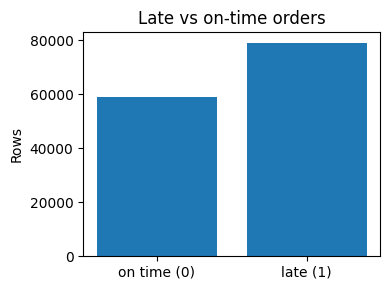

In [6]:
counts = y.value_counts().sort_index()
print((counts / counts.sum() * 100).round(1).rename(index={0: "on time (0)", 1: "late (1)"}))
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["on time (0)", "late (1)"], counts.values)
ax.set_ylabel("Rows"); ax.set_title("Late vs on-time orders")
show(fig, "01_class_balance")

### 4.2 Late rate by shipping mode
The strongest pattern in this dataset: faster modes promise delivery times that are often missed.

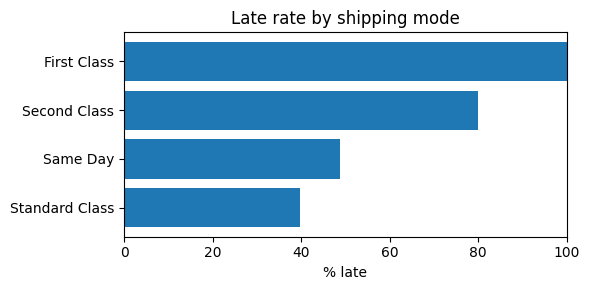

,late_rate,rows
Shipping Mode,,
Standard Class,39.7,82813
Same Day,48.7,7415
Second Class,79.8,26960
First Class,100.0,21043


In [7]:
by_mode = y.groupby(train["Shipping Mode"]).agg(late_rate="mean", rows="size").sort_values("late_rate")
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(by_mode.index, by_mode["late_rate"] * 100)
ax.set_xlabel("% late"); ax.set_xlim(0, 100); ax.set_title("Late rate by shipping mode")
show(fig, "02_late_rate_by_mode")
by_mode.assign(late_rate=lambda d: (d["late_rate"] * 100).round(1))

## Step 5 – Categorical columns vs the late rate
### 5.1 Strength of each categorical column (eta²)
For a yes/no target, **eta²** measures how much the **late rate differs between the groups** of a column (0 = no difference, 1 = the column
decides lateness completely). Columns with thousands of values get an inflated score by chance, so `n_categories` is shown too.

In [8]:
def eta_squared(cat, target):
    overall = target.mean()
    g = target.groupby(cat)
    ss_between = (g.size() * (g.mean() - overall) ** 2).sum()
    ss_total = ((target - overall) ** 2).sum()
    return ss_between / ss_total

cat_strength = pd.DataFrame({
    "n_categories": [train[c].nunique() for c in CATEGORICAL],
    "eta_squared": [eta_squared(train[c], y) for c in CATEGORICAL],
    "late_rate_range_%": [(y.groupby(train[c]).mean().max() - y.groupby(train[c]).mean().min()) * 100 for c in CATEGORICAL],
}, index=CATEGORICAL).sort_values("eta_squared", ascending=False)
cat_strength.round(4)

,n_categories,eta_squared,late_rate_range_%
Shipping Mode,4,0.2313,60.3118
Order City,3495,0.0958,100.0000
Order State,1062,0.0290,100.0000
Customer City,563,0.0138,87.5000
Order Country,161,0.0041,100.0000
Product Name,118,0.0008,39.3162
Customer State,45,0.0007,64.6154
Order Region,23,0.0006,9.9131
Category Name,50,0.0004,23.0463
Market,5,0.0001,0.9739


### 5.2 Late rate by market

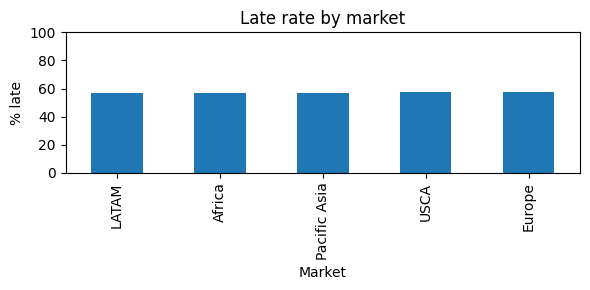

In [9]:
by_market = y.groupby(train["Market"]).mean().sort_values() * 100
fig, ax = plt.subplots(figsize=(6, 3))
by_market.plot.bar(ax=ax)
ax.set_ylabel("% late"); ax.set_ylim(0, 100); ax.set_title("Late rate by market")
show(fig, "03_late_rate_by_market")

### 5.3 Customer segment and product category

In [10]:
print((y.groupby(train["Customer Segment"]).agg(late_rate="mean", rows="size")).assign(late_rate=lambda d: (d.late_rate * 100).round(1)), "\n")
top_cat = y.groupby(train["Category Name"]).agg(late_rate="mean", rows="size").sort_values("rows", ascending=False).head(10)
print("Top 10 categories by rows:\n", top_cat.assign(late_rate=lambda d: (d.late_rate * 100).round(1)))

                  late_rate   rows
Customer Segment                  
Consumer               57.1  71651
Corporate              56.9  41795
Home Office            57.9  24785 

Top 10 categories by rows:
                       late_rate   rows
Category Name                         
Cleats                     57.5  18833
Men's Footwear             57.1  17059
Women's Apparel            57.0  16120
Indoor/Outdoor Games       56.8  14769
Fishing                    57.2  13223
Water Sports               57.1  11925
Camping & Hiking           56.7  10565
Cardio Equipment           56.7   9548
Shop By Sport              57.7   8389
Electronics                58.6   2412


## Step 6 – Numeric columns vs the target, and correlation
### 6.1 Late vs on-time averages
For each numeric column: the average for late orders, for on-time orders, and the correlation with the 0/1 label.

In [11]:
num_vs_target = pd.DataFrame({
    "mean_on_time": train.loc[y == 0, NUMERIC].mean(),
    "mean_late": train.loc[y == 1, NUMERIC].mean(),
    "correlation_with_late": train[NUMERIC].corrwith(y),
}).sort_values("correlation_with_late", key=abs, ascending=False)
num_vs_target.round(3)

,mean_on_time,mean_late,correlation_with_late
Sales per customer,184.035,182.465,-0.006
Sales,204.728,203.020,-0.006
Product Price,142.093,140.685,-0.005
Benefit per order,22.587,21.878,-0.003
Order Item Discount,20.692,20.556,-0.003
Order Item Profit Ratio,0.122,0.120,-0.002
Category Id,31.873,31.829,-0.001
Longitude,-84.875,-84.910,-0.001
Order Item Quantity,2.126,2.128,0.001
Latitude,29.707,29.714,0.000


### 6.2 Correlation heatmap
Strongly related inputs make linear-model coefficients unstable; trees are much less affected.

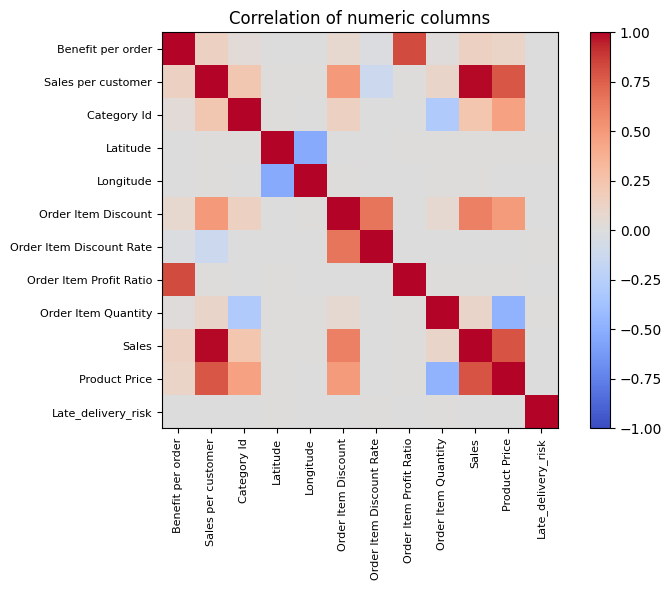

In [12]:
corr = train[NUMERIC + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im, ax=ax); ax.set_title("Correlation of numeric columns")
show(fig, "04_correlation_heatmap")

### 6.3 Highly correlated pairs (|r| > 0.9)

In [13]:
pairs = corr.drop(index=TARGET, columns=TARGET).stack()
pairs = pairs[[a < b for a, b in pairs.index]]
high = pairs[pairs.abs() > 0.9].sort_values(key=abs, ascending=False)
print(high.round(3) if len(high) else "none")

Sales  Sales per customer    0.99
dtype: float64


## Step 7 – Outliers, skew and consistency checks
### 7.1 Outlier share and skewness (IQR rule)

In [14]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() * 100

outliers = pd.DataFrame({
    "outliers_%": [iqr_outliers(train[c]) for c in NUMERIC],
    "skew": [train[c].skew() for c in NUMERIC],
    "min": [train[c].min() for c in NUMERIC],
    "max": [train[c].max() for c in NUMERIC],
}, index=NUMERIC).sort_values("outliers_%", ascending=False)
outliers.round(2)

,outliers_%,skew,min,max
Benefit per order,10.47,-4.39,-3442.50,911.80
Order Item Profit Ratio,9.57,-2.89,-2.75,0.50
Order Item Discount,4.12,3.07,0.00,500.00
Product Price,1.13,3.22,9.99,1999.99
Sales per customer,1.06,2.91,7.49,1939.99
Longitude,0.79,-0.47,-158.03,115.26
Sales,0.27,2.92,9.99,1999.99
Latitude,0.01,-0.10,-33.94,48.78
Category Id,0.00,0.36,2.00,76.00
Order Item Discount Rate,0.00,0.34,0.00,0.25


### 7.2 Boxplot of the financial columns

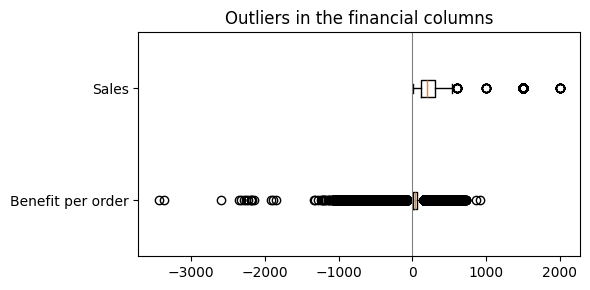

In [15]:
money = [c for c in ["Benefit per order", "Sales"] if c in train.columns]
fig, ax = plt.subplots(figsize=(6, 3))
ax.boxplot([train[c] for c in money], vert=False)
ax.set_yticks(range(1, len(money) + 1)); ax.set_yticklabels(money)
ax.axvline(0, color="grey", lw=0.8); ax.set_title("Outliers in the financial columns")
show(fig, "05_boxplot_financial")

### 7.3 Negative profits – error or real?
Negative profit is a **genuine loss** (7.4 shows the money columns add up correctly), so these rows are **kept**.

In [16]:
neg = train["Benefit per order"] < 0
print(f"Rows with negative Benefit per order: {neg.mean() * 100:.1f}% (min {train['Benefit per order'].min():,.2f})")
print(f"Late rate | loss: {y[neg].mean() * 100:.1f}% | profit: {y[~neg].mean() * 100:.1f}%")

Rows with negative Benefit per order: 18.7% (min -3,442.50)
Late rate | loss: 57.1% | profit: 57.2%


### 7.4 Consistency checks (invalid records)

In [17]:
price_col = "Product Price" if "Product Price" in train.columns else "Order Item Product Price"
checks = {}
if "Sales" in train.columns:
    checks["Sales = Price x Quantity"] = np.isclose(train["Sales"], train[price_col] * train["Order Item Quantity"], atol=0.05)
    checks["Sales per customer = Sales - Discount"] = np.isclose(train["Sales per customer"], train["Sales"] - train["Order Item Discount"], atol=0.05)
checks["Discount Rate between 0 and 1"] = train["Order Item Discount Rate"].between(0, 1)
pd.Series({k: f"{v.mean() * 100:.2f}% of rows" for k, v in checks.items()}, name="holds for")

Sales = Price x Quantity                 100.00% of rows
Sales per customer = Sales - Discount    100.00% of rows
Discount Rate between 0 and 1            100.00% of rows
Name: holds for, dtype: object

## Step 8 – Time patterns
### 8.1 Late rate by order weekday

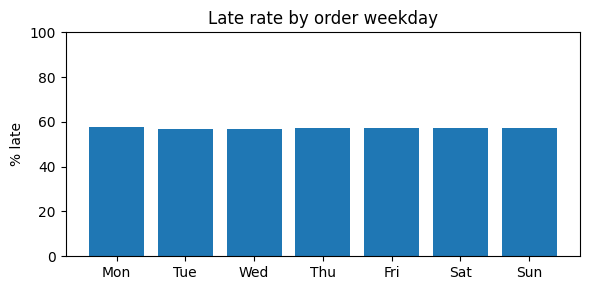

In [18]:
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_weekday = y.groupby(train["order_dt"].dt.weekday).mean() * 100
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([DAYS[i] for i in by_weekday.index], by_weekday.values)
ax.set_ylabel("% late"); ax.set_ylim(0, 100); ax.set_title("Late rate by order weekday")
show(fig, "06_late_by_weekday")

### 8.2 Late rate by order hour

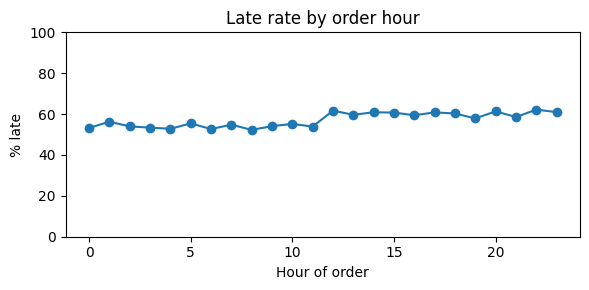

In [19]:
by_hour = y.groupby(train["order_dt"].dt.hour).mean() * 100
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(by_hour.index, by_hour.values, marker="o")
ax.set_xlabel("Hour of order"); ax.set_ylabel("% late"); ax.set_ylim(0, 100); ax.set_title("Late rate by order hour")
show(fig, "07_late_by_hour")

### 8.3 Late rate over time (drift check)
A stable line means behaviour does not drift over 2015–2018, so a grouped random split is acceptable.

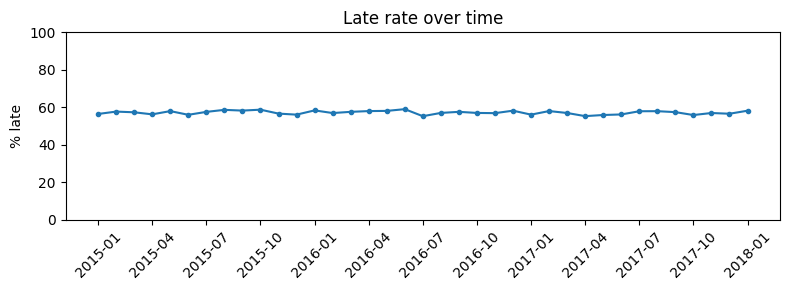

       late_rate    orders
count     37.000    37.000
mean       0.572  1359.946
std        0.010    95.940
min        0.552  1207.000
25%        0.564  1313.000
50%        0.573  1346.000
75%        0.579  1362.000
max        0.590  1629.000


In [20]:
monthly = train.groupby(train["order_dt"].dt.to_period("M")).agg(late_rate=(TARGET, "mean"), orders=(GROUP, "nunique"))
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(monthly.index.astype(str), monthly["late_rate"] * 100, marker=".")
ax.set_ylabel("% late"); ax.set_ylim(0, 100); ax.set_title("Late rate over time")
ax.set_xticks(range(0, len(monthly), max(1, len(monthly) // 12))); ax.tick_params(axis="x", rotation=45)
show(fig, "08_late_over_time")
print(monthly.describe().round(3))

## Step 9 – Feature engineering: date features
### 9.1 The date-feature function
**order_weekday** (0 = Monday), **order_month**, **order_hour**, **order_quarter**, **is_weekend**.
**No leakage:** each row uses only its own order date, which is known when the order is placed. Nothing is learned from other rows or the label.

In [21]:
DATE_FEATURES = ["order_weekday", "order_month", "order_hour", "order_quarter", "is_weekend"]

def add_date_features(df):
    out = df.copy()
    d = pd.to_datetime(out[DATE_COL], format=DATE_FMT, errors="coerce")
    out["order_weekday"] = d.dt.weekday
    out["order_month"] = d.dt.month
    out["order_hour"] = d.dt.hour
    out["order_quarter"] = d.dt.quarter
    out["is_weekend"] = (d.dt.weekday >= 5).astype(int)
    return out

train_fe = add_date_features(train.drop(columns=["order_dt"]))
train_fe[[DATE_COL] + DATE_FEATURES].head()

,order date (DateOrders),order_weekday,order_month,order_hour,order_quarter,is_weekend
0,1/31/2018 22:56,2,1,22,1,0
1,1/13/2018 12:06,5,1,12,1,1
2,1/13/2018 11:45,5,1,11,1,1
3,1/13/2018 11:24,5,1,11,1,1
4,1/13/2018 10:42,5,1,10,1,1


### 9.2 Are the date features related to the late rate?

In [22]:
date_strength = pd.Series({f: eta_squared(train_fe[f], y) for f in DATE_FEATURES + ["Shipping Mode"]}, name="eta_squared")
date_strength.sort_values(ascending=False).round(4).to_frame()

,eta_squared
Shipping Mode,0.2313
order_hour,0.0047
order_month,0.0001
order_weekday,0.0000
order_quarter,0.0000
is_weekend,0.0000


## Step 10 – Save the train and test files with date features
The test set is loaded here for the first time and **only** gets the same date features.

In [23]:
test = pd.read_csv(PROCESSED_DIR / "test_clf.csv")
test_fe = add_date_features(test)
train_fe.to_csv(PROCESSED_DIR / "train_clf_fe.csv", index=False)
test_fe.to_csv(PROCESSED_DIR / "test_clf_fe.csv", index=False)
print("Saved train_clf_fe.csv", train_fe.shape, "and test_clf_fe.csv", test_fe.shape)

Saved train_clf_fe.csv (138231, 33) and test_clf_fe.csv (34534, 33)


## Step 11 – Key findings summary

In [24]:
print(f'''
TARGET          {y.mean() * 100:.1f}% late, {100 - y.mean() * 100:.1f}% on time
LATE BY MODE    {", ".join(f"{m} {r * 100:.0f}%" for m, r in by_mode["late_rate"].items())}
SHIPPING MODE   eta^2 = {eta_squared(train["Shipping Mode"], y):.3f}
TOP CATEGORICAL {", ".join(f"{c} ({v:.3f})" for c, v in cat_strength["eta_squared"].head(3).items())}
TOP NUMERIC     {", ".join(f"{c} ({v:+.3f})" for c, v in num_vs_target["correlation_with_late"].head(3).items())}
REDUNDANT PAIRS {len(high)} numeric pairs with |r| > 0.9
NEGATIVE PROFIT {neg.mean() * 100:.1f}% of rows (kept - genuine losses)
MISSING / DUPS  {int(missing.sum())} missing cells, {train.duplicated().sum()} duplicate rows
DATE FEATURES   {", ".join(DATE_FEATURES)}
''')


TARGET          57.2% late, 42.8% on time
LATE BY MODE    Standard Class 40%, Same Day 49%, Second Class 80%, First Class 100%
SHIPPING MODE   eta^2 = 0.231
TOP CATEGORICAL Shipping Mode (0.231), Order City (0.096), Order State (0.029)
TOP NUMERIC     Sales per customer (-0.006), Sales (-0.006), Product Price (-0.005)
REDUNDANT PAIRS 1 numeric pairs with |r| > 0.9
NEGATIVE PROFIT 18.7% of rows (kept - genuine losses)
MISSING / DUPS  0 missing cells, 0 duplicate rows
DATE FEATURES   order_weekday, order_month, order_hour, order_quarter, is_weekend



**My contribution in one sentence:** I explored the training data to find what relates to late delivery, checked data quality,
outliers and time patterns, and created the date features used by the model.